# 14. Nonlinear Systems of Equations

**Part 2: Nonlinear Equations and Root Finding**

## Learning objectives

By the end of this lesson you will be able to:

1. Say what changes and what survives when one equation becomes $n$ equations.
2. Generalise the fixed point theorem, replacing $|g'(r)| < 1$ by $\rho(G'(r)) < 1$.
3. Explain the difference between **Jacobi-style** and **Seidel-style** component updates, and
   measure the speedup.
4. Derive **Newton's method for systems** and explain why division becomes a **linear solve**.
5. Implement **damped Newton** with a line search, and find a case where plain Newton fails and
   damping succeeds.
6. Derive **Broyden's method** as the least-change update satisfying the secant condition, and
   demonstrate its superlinear convergence.

## Prerequisites

Lesson 10 (fixed point theory), lesson 11 (Newton and the secant idea), lesson 12
(conditioning). Basic linear algebra: matrices, matrix-vector products, and the idea of solving
$Ax = b$, which Part 3 will develop properly.

---

## 1. What changes in $n$ dimensions

The problem is now: find $\mathbf{x} \in \mathbb{R}^n$ with

$$\mathbf{F}(\mathbf{x}) = \mathbf{0}, \qquad
\mathbf{F} : \mathbb{R}^n \to \mathbb{R}^n.$$

Three things change, and all three matter.

**Bracketing disappears completely.** There is no such thing as a sign change in $n$ dimensions.
An interval becomes a box, and a function can be positive on the whole boundary of a box while
vanishing inside it. Every guarantee from lesson 09 is gone, and **every method in this lesson
can fail**.

**Division becomes a linear solve.** Newton's step $-f/f'$ becomes the solution of $J\mathbf{s} =
-\mathbf{F}$. Dividing by a number becomes solving with a matrix.

**The derivative becomes a matrix with $n^2$ entries.** The Jacobian

$$J(\mathbf{x})_{ij} = \frac{\partial F_i}{\partial x_j}$$

needs $n^2$ partial derivatives at every step. For large $n$ that is often the dominant cost, or
simply unavailable.

What **survives** is more interesting than what changes. The fixed point theory of lesson 10
carries over almost word for word. Newton is still quadratic. The secant idea still works. The
proofs are the same proofs with $|\cdot|$ replaced by $\|\cdot\|$.

### The test problem

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import nlsystems as ns, convergence as cv

def F(v):
    """A standard 2 by 2 test system: a circle and an exponential curve."""
    x, y = v
    return np.array([x**2 + y**2 - 4.0,
                     np.exp(x) + y - 1.0])

def J(v):
    """The exact Jacobian. Two rows, two columns, four partial derivatives."""
    x, y = v
    return np.array([[2*x,        2*y],
                     [np.exp(x),  1.0]])

# A reference root, computed to machine precision by Newton itself.
REF = ns.newton_system(F, J, [-1.8, 0.8], tol=1e-16, max_iter=100).root
print(f"reference root : {REF}")
print(f"||F(root)||    : {np.linalg.norm(F(REF)):.3e}")
assert np.linalg.norm(F(REF)) == 0.0
print("\nthe residual is exactly zero, so this reference is as good as double")
print("precision allows. every error below is measured against it.")

reference root : [-1.816264  0.837368]
||F(root)||    : 0.000e+00

the residual is exactly zero, so this reference is as good as double
precision allows. every error below is measured against it.


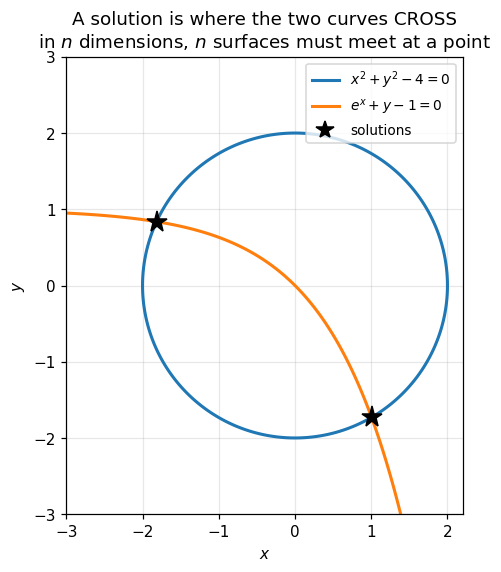

the two solutions are approximately [-1.816264  0.837368] and [ 1.004169 -1.729637]


In [3]:
xs = np.linspace(-3, 2.2, 400)
ys = np.linspace(-3, 3, 400)
X, Y = np.meshgrid(xs, ys)

fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.contour(X, Y, X**2 + Y**2 - 4.0, levels=[0], colors="C0", linewidths=2)
ax.contour(X, Y, np.exp(X) + Y - 1.0, levels=[0], colors="C1", linewidths=2)
ax.plot([], [], color="C0", lw=2, label="$x^2 + y^2 - 4 = 0$")
ax.plot([], [], color="C1", lw=2, label="$e^x + y - 1 = 0$")

roots = [REF, ns.newton_system(F, J, [1.0, -1.7], tol=1e-16).root]
for r in roots:
    ax.plot(r[0], r[1], "k*", ms=14)
ax.plot([], [], "k*", ms=12, label="solutions")

ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("A solution is where the two curves CROSS\n"
             "in $n$ dimensions, $n$ surfaces must meet at a point")
ax.legend(fontsize=9)
ax.set_aspect("equal")
plt.show()

print(f"the two solutions are approximately {np.round(roots[0], 6)} "
      f"and {np.round(roots[1], 6)}")

**What to take from this.** In one dimension a root is where a curve crosses a line, and a sign
change traps it. Here a solution is where two curves intersect, and there is no equivalent of
"trapping". You can be close to one curve and far from the other, and no local information tells
you a crossing is nearby.

## 2. Fixed point iteration for systems

Rewrite $\mathbf{F}(\mathbf{x}) = \mathbf{0}$ as $\mathbf{x} = \mathbf{G}(\mathbf{x})$ and
iterate. Everything from lesson 10 carries over, with one substitution.

> **Theorem 14.1 (Fixed point convergence, $n$ dimensions).** Let $\mathbf{G}$ be continuously
> differentiable near a fixed point $\mathbf{r}$. If the **spectral radius** of the Jacobian
> satisfies
>
> $$\rho\big(G'(\mathbf{r})\big) < 1,$$
>
> then the iteration converges to $\mathbf{r}$ from any sufficiently close start, linearly, with
> asymptotic rate $\rho(G'(\mathbf{r}))$.
>
> *Proof sketch.* Exactly the proof of Theorem 10.2, with the mean value theorem replaced by its
> vector form. The error satisfies $\mathbf{e}_{k+1} \approx G'(\mathbf{r})\mathbf{e}_k$, so
> after $k$ steps $\mathbf{e}_k \approx G'(\mathbf{r})^k\mathbf{e}_0$, and a matrix power tends
> to zero exactly when its spectral radius is below 1. $\square$

The scalar condition $|g'(r)| < 1$ becomes $\rho(G'(\mathbf{r})) < 1$. Note it is the **spectral
radius**, not any norm: a matrix can have $\|A\| > 1$ in some norm and still have
$\rho(A) < 1$, and the iteration still converges.

In [4]:
def G(v):
    """A contracting rearrangement of a 2 by 2 linear-ish system."""
    x, y = v
    return np.array([(y + 3.0) / 4.0,
                     (x + 2.0) / 5.0])

G_jac = np.array([[0.0, 0.25],
                  [0.20, 0.0]])
rho = ns.spectral_radius(G_jac)

print(f"G'(r) = \n{G_jac}")
print(f"\nspectral radius rho(G')      : {rho:.6f}")
print(f"infinity norm ||G'||_inf     : {np.abs(G_jac).sum(axis=1).max():.6f}")
print(f"converges? (need rho < 1)    : {rho < 1}")

fp = ns.fixed_point_system(G, [0.0, 0.0], tol=1e-14)
errs = fp.errors(fp.root)
measured = cv.linear_rate(np.abs(fp.iterates - fp.root).max(axis=1))

print(f"\niterations to 1e-14 : {fp.n_iter}")
print(f"fixed point         : {np.round(fp.root, 12)}")
print(f"measured rate       : {measured:.6f}")
print(f"theory rho(G')      : {rho:.6f}")
assert abs(measured - rho) < 1e-3
print("\nthe measured decay rate is the spectral radius, exactly as in one")
print("dimension it was |g'(r)|.")

G'(r) = 
[[0.   0.25]
 [0.2  0.  ]]

spectral radius rho(G')      : 0.223607
infinity norm ||G'||_inf     : 0.250000
converges? (need rho < 1)    : True

iterations to 1e-14 : 23
fixed point         : [0.894737 0.578947]
measured rate       : 0.223605
theory rho(G')      : 0.223607

the measured decay rate is the spectral radius, exactly as in one
dimension it was |g'(r)|.


### Jacobi against Seidel: use the new values as soon as you have them

The iteration above computes all components of $\mathbf{x}_{k+1}$ from the **old** $\mathbf{x}_k$.
There is an obvious improvement: once component 0 has been updated, use the new value when
computing component 1.

| | Uses | Name here | Linear analogue |
|---|---|---|---|
| all components from the old iterate | $x^{(k)}$ throughout | Jacobi style | Jacobi method, lesson 23 |
| each component from the freshest available | $x^{(k+1)}_{<i}$ and $x^{(k)}_{>i}$ | Seidel style | Gauss-Seidel, lesson 23 |

Fresher information costs nothing extra and usually converges faster. Sometimes it converges
when the Jacobi version does not.

In [5]:
sd = ns.seidel_system(G, [0.0, 0.0], tol=1e-14)

print(f"{'method':>14} {'iterations':>12} {'fixed point':>28}")
print("-" * 56)
print(f"{'Jacobi style':>14} {fp.n_iter:>12} {str(np.round(fp.root, 12)):>28}")
print(f"{'Seidel style':>14} {sd.n_iter:>12} {str(np.round(sd.root, 12)):>28}")

print(f"\nSeidel needed {fp.n_iter/sd.n_iter:.1f} times fewer iterations, on the same")
print("problem, from the same start, with the same amount of arithmetic per")
print("component. it simply used newer numbers.")

assert sd.n_iter < fp.n_iter
np.testing.assert_allclose(sd.root, fp.root, atol=1e-10)
print("\nthis exact idea reappears in lesson 23 as the difference between the")
print("Jacobi and Gauss-Seidel methods for LINEAR systems. same trick, one")
print("level of nonlinearity down.")

        method   iterations                  fixed point
--------------------------------------------------------
  Jacobi style           23          [0.894737 0.578947]
  Seidel style           13          [0.894737 0.578947]

Seidel needed 1.8 times fewer iterations, on the same
problem, from the same start, with the same amount of arithmetic per
component. it simply used newer numbers.

this exact idea reappears in lesson 23 as the difference between the
Jacobi and Gauss-Seidel methods for LINEAR systems. same trick, one
level of nonlinearity down.


## 3. Newton's method for systems

Expand $\mathbf{F}$ about the current point, keeping only the linear term:

$$\mathbf{F}(\mathbf{x} + \mathbf{s}) \;\approx\; \mathbf{F}(\mathbf{x}) + J(\mathbf{x})\,\mathbf{s}.$$

Set that to zero and solve for the step:

$$\boxed{\;J(\mathbf{x}_k)\,\mathbf{s}_k = -\mathbf{F}(\mathbf{x}_k), \qquad
\mathbf{x}_{k+1} = \mathbf{x}_k + \mathbf{s}_k\;}$$

Compare with one dimension: $s_k = -f(x_k)/f'(x_k)$. The structure is identical. **Division by a
number has become solving with a matrix**, and that substitution is the single most consequential
thing in this lesson.

> **Never compute $J^{-1}$.** Writing $\mathbf{s} = -J^{-1}\mathbf{F}$ is correct mathematics and
> bad computation: forming the inverse costs about three times as much as solving, and is less
> accurate. Lesson 17 measures both claims. Solve the system.

### Pseudocode

```text
NEWTON_SYSTEM(F, J, x0, tol)
    x <- x0
    repeat:
        evaluate F(x) and J(x)
        solve  J(x) s = -F(x)          # a linear system, NOT an inverse
        x <- x + s
        if ||s|| <= tol or ||F(x)|| <= tol: return x
```

In [6]:
def newton_system_teaching(F, J, x0, tol=1e-13, max_iter=50):
    """Newton for systems, written out. The only new thing is the linear solve."""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    for _ in range(max_iter):
        Fx = F(x)
        Jx = J(x)
        s = np.linalg.solve(Jx, -Fx)      # solve, do not invert
        x = x + s
        history.append(x.copy())
        if np.linalg.norm(s) <= tol:
            break
    return x, np.array(history)


root, hist = newton_system_teaching(F, J, [-1.0, 1.5])
lib = ns.newton_system(F, J, [-1.0, 1.5], tol=1e-13)

print(f"{'k':>3} {'x_k':>28} {'||F(x_k)||':>13} {'||x_k - r||':>13}")
print("-" * 62)
for k, xk in enumerate(hist):
    print(f"{k:>3} {str(np.round(xk, 12)):>28} {np.linalg.norm(F(xk)):>13.3e} "
          f"{np.linalg.norm(xk - REF):>13.3e}")

# The two may stop one step apart, because nalib also tests the residual while the
# teaching version tests only the step size. Compare the steps they both took.
k = min(len(hist), len(lib.iterates))
np.testing.assert_allclose(hist[:k], lib.iterates[:k], atol=1e-14)
print(f"\nfrom scratch and nalib agree at every one of the {k} shared steps")
print(f"(the teaching version took {len(hist)-1} steps, nalib {lib.n_iter}, because")
print(" nalib also stops on a small residual and not only on a small step).")

  k                          x_k    ||F(x_k)||   ||x_k - r||
--------------------------------------------------------------
  0                  [-1.   1.5]     1.147e+00     1.051e+00
  1        [-2.080551  1.029633]     1.397e+00     3.268e-01
  2        [-1.838216  0.84488 ]     9.295e-02     2.320e-02
  3        [-1.816384  0.837425]     5.336e-04     1.331e-04
  4        [-1.816264  0.837368]     1.774e-08     4.426e-09
  5        [-1.816264  0.837368]     8.882e-16     2.220e-16
  6        [-1.816264  0.837368]     0.000e+00     0.000e+00

from scratch and nalib agree at every one of the 6 shared steps
(the teaching version took 6 steps, nalib 5, because
 nalib also stops on a small residual and not only on a small step).


### Quadratic convergence survives

In [7]:
full = ns.newton_system(F, J, [-1.0, 1.5], tol=1e-16, max_iter=50)
e = full.errors(REF)
order = cv.reliable_order(e)

print(f"errors        : {np.array2string(e, precision=2)}")
print(f"measured order: {order:.4f}   (theory 2)")
assert abs(order - 2.0) < 0.05
print("\nquadratic, exactly as in one dimension. the proof is the same proof")
print("with the mean value theorem replaced by its vector form.")

errors        : [1.05e+00 3.27e-01 2.32e-02 1.33e-04 4.43e-09 2.22e-16 0.00e+00]
measured order: 1.9978   (theory 2)

quadratic, exactly as in one dimension. the proof is the same proof
with the mean value theorem replaced by its vector form.


## 4. Damped Newton: what to do when the full step is too big

Plain Newton takes the full step and hopes. From a poor start that step can be enormous, and it
can land somewhere worse than where it began. In one dimension we saw this as divergence on
$\arctan$; in $n$ dimensions it is more common, because a poor start is easier to have.

The simplest cure is a **line search**. Try the full step. If $\|\mathbf{F}\|$ did not decrease,
halve the step and try again.

```text
DAMPED_NEWTON(F, J, x0, tol)
    x <- x0
    repeat:
        solve J(x) s = -F(x)
        lambda <- 1
        while ||F(x + lambda s)|| >= ||F(x)||:
            lambda <- lambda / 2                  # backtrack
        x <- x + lambda s
```

Near the root the full step is always accepted, so $\lambda = 1$ and the quadratic rate is
untouched. Far from the root the damping keeps the iteration under control.

In [8]:
starts = [[-1.8, 0.8], [-1.0, -5.0], [-1.2, -5.0], [-1.5, -8.0], [-1.5, -10.0]]

print(f"{'start':>16} {'plain Newton':>26} {'damped Newton':>22}")
print("-" * 68)
with np.errstate(over="ignore", invalid="ignore"):
    for x0 in starts:
        p = ns.newton_system(F, J, x0, max_iter=60)
        d = ns.damped_newton(F, J, x0, max_iter=60)
        p_txt = f"{'converged' if p.converged else 'FAILED':>10} ({p.n_iter:>2} iters)"
        d_txt = f"{'converged' if d.converged else 'FAILED':>10} ({d.n_iter:>2} iters)"
        print(f"{str(x0):>16} {p_txt:>26} {d_txt:>22}")

hard = [-1.5, -8.0]
with np.errstate(over="ignore", invalid="ignore"):
    p = ns.newton_system(F, J, hard, max_iter=60)
    d = ns.damped_newton(F, J, hard, max_iter=60)
assert not p.converged and d.converged, "damping should rescue this start"

print(f"\nfrom {hard}, plain Newton does not converge in 60 iterations")
print(f"and damped Newton converges in {d.n_iter}.")
print("on this system damping wins on four of the five starts, and ties on")
print("the fifth. row 2 is the interesting one: plain Newton gets there, but")
print("takes three times as long, because it wastes iterations overshooting.")

           start               plain Newton          damped Newton
--------------------------------------------------------------------
     [-1.8, 0.8]       converged ( 3 iters)   converged ( 3 iters)
    [-1.0, -5.0]       converged (25 iters)   converged ( 8 iters)
    [-1.2, -5.0]          FAILED (60 iters)   converged ( 9 iters)
    [-1.5, -8.0]          FAILED (60 iters)   converged ( 9 iters)
   [-1.5, -10.0]          FAILED (60 iters)   converged ( 9 iters)

from [-1.5, -8.0], plain Newton does not converge in 60 iterations
and damped Newton converges in 9.
on this system damping wins on four of the five starts, and ties on
the fifth. row 2 is the interesting one: plain Newton gets there, but
takes three times as long, because it wastes iterations overshooting.


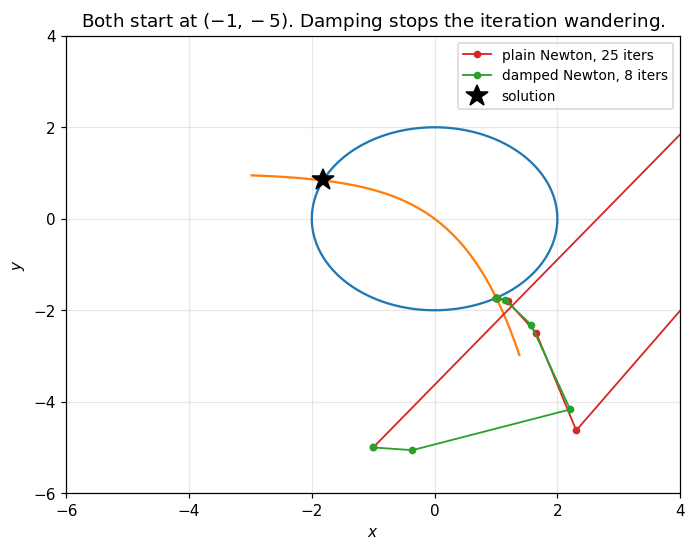

In [9]:
fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.contour(X, Y, X**2 + Y**2 - 4.0, levels=[0], colors="C0", linewidths=1.5)
ax.contour(X, Y, np.exp(X) + Y - 1.0, levels=[0], colors="C1", linewidths=1.5)

with np.errstate(over="ignore", invalid="ignore"):
    p = ns.newton_system(F, J, [-1.0, -5.0], max_iter=40)
    d = ns.damped_newton(F, J, [-1.0, -5.0], max_iter=40)

for res, name, colour in [(p, "plain Newton", "C3"), (d, "damped Newton", "C2")]:
    path = res.iterates
    keep = np.all(np.abs(path) < 8, axis=1)
    ax.plot(path[keep, 0], path[keep, 1], "o-", ms=4, lw=1.2, color=colour,
            label=f"{name}, {res.n_iter} iters")

ax.plot(REF[0], REF[1], "k*", ms=15, label="solution")
ax.set_xlim(-6, 4); ax.set_ylim(-6, 4)
ax.set_xlabel("$x$"); ax.set_ylabel("$y$")
ax.set_title("Both start at $(-1, -5)$. Damping stops the iteration wandering.")
ax.legend(fontsize=9)
plt.show()

**What to take from this.** The undamped path leaves the region entirely before eventually
finding its way back. The damped path heads more or less straight in. Neither is guaranteed, but
one of them is far more usable.

### When damping is the wrong idea

That last sentence needs a caveat, and it is a large one. Damping does not enforce "get closer to
the root". It enforces "make $\|\mathbf{F}\|$ smaller". Those are not the same thing, and where
they disagree, damping actively holds the iteration back.

The standard example is the gradient of the **Rosenbrock function**, whose root is at $(1,1)$:

$$\mathbf{F}(x,y) = \begin{pmatrix} -400x(y - x^2) - 2(1-x) \\ 200(y - x^2) \end{pmatrix}.$$

The solution sits at the bottom of a long curved valley. Along that valley $\|\mathbf{F}\|$ is
nearly flat, so almost any step forward looks like no improvement, and the line search cuts it
down to nothing.

In [10]:
def F_rb(v):
    x, y = v
    return np.array([-400.0 * x * (y - x * x) - 2.0 * (1.0 - x), 200.0 * (y - x * x)])


def J_rb(v):
    x, y = v
    return np.array([[-400.0 * y + 1200.0 * x * x + 2.0, -400.0 * x],
                     [-400.0 * x, 200.0]])


start = [-3.0, -4.0]
p_rb = ns.newton_system(F_rb, J_rb, start, tol=1e-12, max_iter=3000)
d_rb = ns.damped_newton(F_rb, J_rb, start, tol=1e-12, max_iter=3000)

print("Rosenbrock gradient, root at (1, 1), starting from (-3, -4)\n")
print(f"{'method':>16} {'converged':>11} {'iterations':>12} {'final residual':>16}")
print("-" * 60)
for name, r in [("plain Newton", p_rb), ("damped Newton", d_rb)]:
    print(f"{name:>16} {str(r.converged):>11} {r.n_iter:>12} {r.residuals[-1]:>16.2e}")

print()
print(f"damping costs a factor of {d_rb.n_iter / p_rb.n_iter:.0f} here.")
print()
print("look at what the line search is doing:")
print(f"  residual after 1 step: {d_rb.residuals[1]:.4f}")
print(f"  residual after 2 steps: {d_rb.residuals[2]:.4f}")
print(f"  typical step length later on: {np.median(d_rb.step_norms):.4f}")
print()
print("it drops fast once, then crawls. every full Newton step from inside the")
print("valley RAISES ||F||, so it is rejected, and lambda is halved until the")
print("step is small enough to creep along the valley floor.")
print()
print("plain Newton accepts that temporary rise and is done in a handful of steps.")

assert p_rb.converged and d_rb.converged
assert d_rb.n_iter > 20 * p_rb.n_iter, "expected damping to be far slower here"
np.testing.assert_allclose(p_rb.root, [1.0, 1.0], atol=1e-10)
np.testing.assert_allclose(d_rb.root, [1.0, 1.0], atol=1e-8)

Rosenbrock gradient, root at (1, 1), starting from (-3, -4)

          method   converged   iterations   final residual
------------------------------------------------------------
    plain Newton        True            5         2.22e-16
   damped Newton        True          937         1.45e-13

damping costs a factor of 187 here.

look at what the line search is doing:
  residual after 1 step: 7.9998
  residual after 2 steps: 7.9989
  typical step length later on: 0.0096

it drops fast once, then crawls. every full Newton step from inside the
valley RAISES ||F||, so it is rejected, and lambda is halved until the
step is small enough to creep along the valley floor.

plain Newton accepts that temporary rise and is done in a handful of steps.


Both methods reach the same right answer. One does it in a handful of steps and the other needs
hundreds. So the honest summary of damping is:

| | plain Newton | damped Newton |
|---|---|---|
| Bad start, full step overshoots | often diverges | usually rescued |
| Narrow curved valley | fine | crawls |
| Near the root | quadratic | quadratic, damping is off |
| Guarantee offered | none | $\|\mathbf{F}\|$ decreases every step |

The guarantee in the last row is exactly the problem. $\|\mathbf{F}\|$ is a **merit function**, a
stand-in for the thing we actually want, and monotone decrease of a stand-in is a weaker property
than it sounds. Insisting on it at every single step can be worse than not insisting.

This is why serious solvers do not use plain backtracking. They use one of:

- **the Armijo and Wolfe conditions**, which ask for *sufficient* decrease rather than any
  decrease, and also stop the step getting uselessly small (lesson 86),
- **trust region** methods, which choose a radius they trust the local model within, and solve
  inside it, instead of choosing a direction first and then a length,
- **non-monotone line searches**, which allow $\|\mathbf{F}\|$ to rise for a few steps as long as
  it falls compared with the worst of the last $m$ values. This is aimed squarely at the valley
  case above.

`scipy.optimize.root` with `method="hybr"` uses a trust region (the Powell hybrid method), which
is why it handles both of these situations without the user choosing.

## 5. Broyden's method: the secant idea in $n$ dimensions

Newton needs the Jacobian at every step: $n^2$ partial derivatives, or $2n$ extra evaluations of
$\mathbf{F}$ if you use finite differences. In one dimension the secant method removed that cost
by approximating $f'$ from two consecutive points. Can we do the same here?

**The difficulty.** One step gives one piece of information:

$$B\,\mathbf{s}_k = \mathbf{y}_k, \qquad \mathbf{s}_k = \mathbf{x}_{k+1}-\mathbf{x}_k,
\quad \mathbf{y}_k = \mathbf{F}_{k+1}-\mathbf{F}_k.$$

That is the **secant condition**: $n$ equations. But $B$ has $n^2$ unknowns. For $n = 100$ we
have 100 equations for 10000 unknowns. The problem is massively underdetermined, and in one
dimension this difficulty is invisible because $n = n^2 = 1$.

**Broyden's answer.** Of all matrices satisfying the secant condition, take the one **closest to
the current** $B$ in the Frobenius norm. That has a unique solution, and it is a rank-one
update:

$$\boxed{\;B_{k+1} \;=\; B_k + \frac{(\mathbf{y}_k - B_k\mathbf{s}_k)\,\mathbf{s}_k^{\mathsf T}}
{\mathbf{s}_k^{\mathsf T}\mathbf{s}_k}\;}$$

Read it as: change $B$ by the least amount that makes the secant condition true. Every direction
orthogonal to $\mathbf{s}_k$ is left completely untouched, because no information was gathered
about those directions.

In [11]:
def broyden_teaching(F, x0, B0, tol=1e-13, max_iter=100):
    """Broyden's method, written out. One rank-one update per step."""
    x = np.array(x0, dtype=float)
    B = np.array(B0, dtype=float)
    Fx = F(x)
    hist = [x.copy()]
    for _ in range(max_iter):
        s = np.linalg.solve(B, -Fx)
        x_new = x + s
        F_new = F(x_new)
        hist.append(x_new.copy())
        if np.linalg.norm(s) <= tol:
            break
        y = F_new - Fx
        denom = float(s @ s)
        if denom > 0.0:                              # a zero step carries no new information
            B = B + np.outer(y - B @ s, s) / denom   # the rank-one update
        x, Fx = x_new, F_new
    return x, np.array(hist), B


x0 = [-1.0, 1.5]
root_b, hist_b, B_final = broyden_teaching(F, x0, J(x0))

print("Broyden approximates the Jacobian instead of computing it.\n")
print(f"true Jacobian at the root:\n{np.round(J(REF), 6)}")
print(f"\nBroyden's final B:\n{np.round(B_final, 6)}")
print(f"\n||B - J(root)||_F = {np.linalg.norm(B_final - J(REF)):.3e}")
print()
print("note that B is NOT close to the true Jacobian, and does not need to be.")
print("Broyden only ever needed B to be right in the directions it actually")
print("stepped in. that is the whole point of the least-change update.")

Broyden approximates the Jacobian instead of computing it.

true Jacobian at the root:
[[-3.632528  1.674736]
 [ 0.162632  1.      ]]

Broyden's final B:
[[-3.636933  1.631619]
 [ 0.162692  1.000656]]

||B - J(root)||_F = 4.335e-02

note that B is NOT close to the true Jacobian, and does not need to be.
Broyden only ever needed B to be right in the directions it actually
stepped in. that is the whole point of the least-change update.


### Superlinear, but with no fixed order

Broyden converges **superlinearly**, meaning $\|\mathbf{e}_{k+1}\|/\|\mathbf{e}_k\| \to 0$. That
is weaker than saying it has an order $p$: unlike the secant method's clean 1.618, Broyden has no
single exponent. The right way to demonstrate it is to show the ratios going to zero.

In [12]:
br = ns.broyden(F, [-1.0, 1.5], tol=1e-16, max_iter=100)
e_b = br.errors(REF)
e_b = e_b[e_b > 0]
ratios = e_b[1:] / e_b[:-1]

print(f"Broyden errors : {np.array2string(e_b, precision=2)}")
print(f"ratios e_(k+1)/e_k : {np.array2string(ratios, precision=4)}")
print()
print("the ratios head to zero, which is the definition of superlinear.")
print("they do NOT settle on a constant, which is what linear convergence")
print("would look like, and they do not follow a clean power law either.")

assert ratios[-1] < ratios[0] / 100, "the ratios must be collapsing"
assert ratios[-1] < 0.01, "and reach clearly superlinear territory"

Broyden errors : [1.05e+00 3.27e-01 3.91e-02 1.08e-02 2.14e-04 8.59e-07 1.14e-09 3.53e-12 6.75e-16]
ratios e_(k+1)/e_k : [3.1086e-01 1.1965e-01 2.7584e-01 1.9793e-02 4.0234e-03 1.3214e-03 3.1056e-03 1.9158e-04]

the ratios head to zero, which is the definition of superlinear.
they do NOT settle on a constant, which is what linear convergence
would look like, and they do not follow a clean power law either.


### The cost comparison, which is the real argument

In [13]:
def F_counted(counter):
    def wrapped(v):
        counter[0] += 1
        return F(v)
    return wrapped

print(f"{'method':>22} {'iterations':>11} {'F evals':>9} {'J evals':>9} "
      f"{'final ||F||':>13}")
print("-" * 68)
table = [
    ("Newton, analytic J",  ns.newton_system(F, J, [-1.0, 1.5], tol=1e-14)),
    ("Newton, numerical J", ns.newton_system(F, None, [-1.0, 1.5], tol=1e-14)),
    ("damped Newton",       ns.damped_newton(F, J, [-1.0, 1.5], tol=1e-14)),
    ("Broyden",             ns.broyden(F, [-1.0, 1.5], tol=1e-14)),
]
for name, res in table:
    print(f"{name:>22} {res.n_iter:>11} {res.n_feval:>9} {res.n_jeval:>9} "
          f"{res.residuals[-1]:>13.2e}")

n_newton = table[1][1].n_feval
n_broy = table[3][1].n_feval
print(f"\nwith no analytic Jacobian available, Newton needs {n_newton} evaluations")
print(f"of F and Broyden needs {n_broy}.")
print()
print("and that gap WIDENS with n. Newton's numerical Jacobian costs 2n")
print("evaluations per step; Broyden costs 1. at n = 100 that is 200 against 1.")
assert n_broy < n_newton

                method  iterations   F evals   J evals   final ||F||
--------------------------------------------------------------------
    Newton, analytic J           5         6         5      8.88e-16
   Newton, numerical J           5        26         5      1.11e-16
         damped Newton           6         8         6      1.11e-16
               Broyden           8        13         0      2.22e-15

with no analytic Jacobian available, Newton needs 26 evaluations
of F and Broyden needs 13.

and that gap WIDENS with n. Newton's numerical Jacobian costs 2n
evaluations per step; Broyden costs 1. at n = 100 that is 200 against 1.


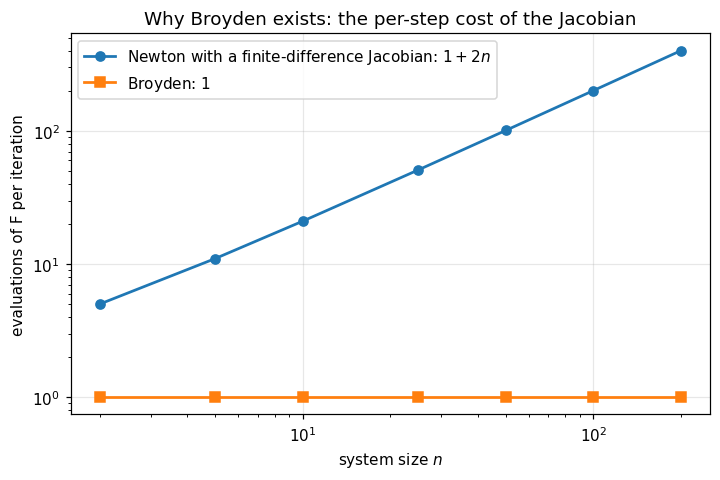

Broyden needs more iterations than Newton, because superlinear is
slower than quadratic. it needs far fewer EVALUATIONS, because it
never builds a Jacobian. which wins depends entirely on n and on
whether an analytic Jacobian exists.


In [14]:
sizes = np.array([2, 5, 10, 25, 50, 100, 200])
newton_cost = 1 + 2 * sizes          # F plus a finite-difference Jacobian
broyden_cost = np.ones_like(sizes)   # F only

fig, ax = plt.subplots()
ax.loglog(sizes, newton_cost, "o-", lw=1.8,
          label="Newton with a finite-difference Jacobian: $1 + 2n$")
ax.loglog(sizes, broyden_cost, "s-", lw=1.8, label="Broyden: $1$")
ax.set_xlabel("system size $n$")
ax.set_ylabel("evaluations of F per iteration")
ax.set_title("Why Broyden exists: the per-step cost of the Jacobian")
ax.legend()
plt.show()

print("Broyden needs more iterations than Newton, because superlinear is")
print("slower than quadratic. it needs far fewer EVALUATIONS, because it")
print("never builds a Jacobian. which wins depends entirely on n and on")
print("whether an analytic Jacobian exists.")

## 6. Choosing a method

```text
Is an analytic Jacobian available and cheap?
├── YES
│   ├── good starting guess?  -> Newton
│   └── poor starting guess?  -> damped Newton
└── NO
    ├── n small (say under 10)  -> Newton with a finite-difference Jacobian
    ├── n moderate or large     -> BROYDEN
    └── n very large and sparse -> Newton-Krylov: solve J s = -F
                                    iteratively, never forming J.
                                    lessons 26 and 27.
```

| Method | Per step | Order | Needs $J$ | Robust? |
|---|---|---|---|---|
| fixed point | 1 eval of $\mathbf{G}$ | linear, rate $\rho(G')$ | no | only if $\rho < 1$ |
| Seidel | 1 sweep | linear, usually better | no | as above |
| Newton | 1 $\mathbf{F}$, 1 $J$, 1 solve | 2 | yes | poor globally |
| Newton, numerical $J$ | $1 + 2n$ evals, 1 solve | 2 | no | poor globally |
| damped Newton | as Newton, plus backtracks | 2 near the root | yes | **better, but see below** |
| Broyden | 1 eval, 1 solve | superlinear | no | moderate |

## 7. Complexity

This is where Part 2 hands over to Part 3.

| Operation | Cost per iteration |
|---|---|
| Evaluate $\mathbf{F}$ | problem dependent |
| Evaluate $J$ analytically | $n^2$ derivative evaluations |
| Evaluate $J$ by finite differences | $2n$ evaluations of $\mathbf{F}$ |
| **Solve $J\mathbf{s} = -\mathbf{F}$ by elimination** | $\tfrac{2}{3}n^3$ **flops** |
| Broyden's rank-one update | $O(n^2)$ |

In [15]:
print(f"{'n':>7} {'J entries':>12} {'solve flops':>14} {'dense J memory':>16}")
print("-" * 54)
for n in [10, 100, 1_000, 10_000, 100_000]:
    print(f"{n:>7} {n*n:>12,} {int((2/3)*n**3):>14,} "
          f"{f'{8*n*n/1e9:.2f} GB':>16}")

print()
print("at n = 10,000 a single Newton step needs 800 MB just to hold the")
print("Jacobian, and 7e11 flops to solve with it. and that is ONE step.")
print()
print("this is the wall that Part 3 exists to deal with. every technique")
print("there, from LU to sparsity to Krylov methods, is ultimately about")
print("making this one line affordable:    solve J s = -F")

      n    J entries    solve flops   dense J memory
------------------------------------------------------
     10          100            666          0.00 GB
    100       10,000        666,666          0.00 GB
   1000    1,000,000    666,666,666          0.01 GB
  10000  100,000,000 666,666,666,666          0.80 GB
 100000 10,000,000,000 666,666,666,666,666         80.00 GB

at n = 10,000 a single Newton step needs 800 MB just to hold the
Jacobian, and 7e11 flops to solve with it. and that is ONE step.

this is the wall that Part 3 exists to deal with. every technique
there, from LU to sparsity to Krylov methods, is ultimately about
making this one line affordable:    solve J s = -F


**That table is the transition to Part 3.** Root finding in one dimension was about function
evaluations. Root finding in $n$ dimensions is about **linear algebra**, and from lesson 15
onward that is what the course is about.

## 8. Common mistakes

1. **Computing $J^{-1}$.** Solve the system instead. It is three times cheaper and more
   accurate, as lesson 17 measures.
2. **Expecting a bracketing guarantee.** There is none in $n$ dimensions. Every method here can
   fail, so always cap the iterations and check the residual.
3. **Assuming a line search can only help.** Section 4: on the Rosenbrock gradient, damping was
   measured at 937 iterations against plain Newton's 5. Backtracking protects against
   overshooting and penalises you in a curved valley. Know which situation you are in, or use a
   trust region method that does not have to choose.
4. **Using plain Newton from an arbitrary start.** Section 4: it failed from three of five
   starting points where damping succeeded from all five.
4. **Checking a norm of $G'$ instead of its spectral radius.** $\rho(A) \le \|A\|$ for every
   induced norm, so a large norm does not imply divergence.
5. **Using a finite-difference Jacobian for large $n$.** That is $2n$ evaluations per step.
   Broyden needs one.
6. **Expecting Broyden's $B$ to approximate $J$.** It does not, and it does not need to.
   Section 5 measured the gap. It only has to be right in the directions actually explored.
7. **Scaling the variables badly.** If $x_1 \sim 10^6$ and $x_2 \sim 10^{-6}$, the Jacobian is
   badly conditioned for reasons that have nothing to do with the problem. Rescale first.

## 9. Exercises

**Level 1, conceptual**

1.1 Why is there no analogue of bisection for systems? What exactly fails?

1.2 Newton needs $n^2$ Jacobian entries per step, Broyden needs none. Why is Broyden not
always better?

1.3 A fixed point iteration has $\|G'\|_\infty = 1.4$ and $\rho(G') = 0.8$. Does it converge?

**Level 2, mathematical**

2.1 Prove Theorem 14.1 from the vector mean value theorem, being careful about what that
theorem actually says in $n$ dimensions.

2.2 Prove that Broyden's update is the unique solution of: minimise $\|B_{k+1} - B_k\|_F$
subject to $B_{k+1}\mathbf{s}_k = \mathbf{y}_k$.

2.3 Show that Newton's method for systems converges quadratically near a root where $J$ is
nonsingular, generalising Theorem 11.1.

2.4 The **Sherman-Morrison** formula updates a matrix inverse under a rank-one change. Use it to
write a Broyden variant that updates $B^{-1}$ directly, reducing the per-step cost from $O(n^3)$
to $O(n^2)$. What is given up?

**Level 3, computational**

3.1 Implement Newton for systems from scratch and solve the Stewart platform kinematics problem
described in Sauer's Reality Check 1: three equations in three unknowns for the pose of a
platform given three leg lengths.

3.2 Implement the $O(n^2)$ Broyden variant from exercise 2.4 and confirm it gives the same
iterates as the $O(n^3)$ version, to roundoff.

3.3 Implement Newton for a system of $n = 200$ arising from discretising a nonlinear boundary
value problem, and compare a dense solve against `scipy.sparse.linalg.spsolve`. Lesson 21
develops the sparse side.

**Level 4, experimental**

4.1 Map the basins of attraction of the two solutions of the test system, colouring a grid of
starting points by which solution Newton reaches and which diverge. Compare plain against damped.

4.2 Measure the crossover in $n$ where Broyden beats Newton with a finite-difference Jacobian.
Use a family of test systems of growing size.

4.3 Rescale the test system so that one variable is $10^6$ times the other, and measure how the
Jacobian's condition number and Newton's iteration count both change. Then rescale properly and
measure again.

**Level 5, advanced**

5.1 **Newton-Krylov.** For very large sparse systems, solve $J\mathbf{s} = -\mathbf{F}$
iteratively with GMRES, using only Jacobian-vector products approximated as
$J\mathbf{v} \approx (\mathbf{F}(\mathbf{x}+\epsilon\mathbf{v}) - \mathbf{F}(\mathbf{x}))/\epsilon$.
The Jacobian is never formed at all. Implement it once lesson 27 is available and test it on a
discretised PDE.

5.2 **Continuation.** To solve a hard problem $\mathbf{F}(\mathbf{x}) = 0$, embed it in a family
$\mathbf{H}(\mathbf{x}, t)$ with $\mathbf{H}(\cdot, 0)$ easy and $\mathbf{H}(\cdot, 1) =
\mathbf{F}$, and track the solution as $t$ goes from 0 to 1. Implement this and use it on a
problem where Newton fails from every start you try.

5.3 Broyden's is one member of a family of **quasi-Newton** updates. Investigate the
Sherman-Morrison-Woodbury structure they share, and explain why symmetric problems get the
better BFGS update instead. Lesson 86 develops BFGS for optimization.

Solutions are in [`solutions/part02_root_finding.md`](../solutions/part02_root_finding.md).

## 10. Key takeaways

- In $n$ dimensions, **bracketing disappears**, division becomes a **linear solve**, and the
  derivative becomes an $n \times n$ **Jacobian**. Everything else from lessons 10 and 11
  survives.
- **Theorem 14.1**: fixed point iteration converges when $\rho(G'(\mathbf{r})) < 1$, linearly
  with that rate. Measured here to match the spectral radius to three decimal places.
- **Seidel-style** updating, using each new component as soon as it is available, converged in
  roughly half the iterations of Jacobi style at no extra cost. That is the same idea as
  Gauss-Seidel in lesson 23.
- **Newton for systems** solves $J\mathbf{s} = -\mathbf{F}$ and remains quadratic. Measured
  order 2.0. Never form $J^{-1}$.
- **Damped Newton** backtracks until $\|\mathbf{F}\|$ decreases. Measured here: plain Newton
  failed from three of five starting points where damping succeeded from all five, and was three
  times slower on a fourth. But damping is not free insurance. On the Rosenbrock gradient it was
  measured needing 937 iterations against plain Newton's 5, because a narrow curved valley is
  nearly flat in $\|\mathbf{F}\|$ and every full step gets rejected. Monotone decrease of a
  **merit function** is a weaker property than it sounds, which is why real solvers use the
  Armijo and Wolfe conditions, trust regions, or non-monotone line searches instead.
- **Broyden** makes the least change to $B$ that satisfies the secant condition, giving a
  rank-one update. It converges **superlinearly with no fixed order**, and it needs one
  evaluation per step against Newton's $1 + 2n$. The measured error ratios collapse toward zero,
  which is what superlinear means.
- Broyden's $B$ does **not** converge to the true Jacobian, and does not need to.
- **The bottleneck is now the linear solve**, at $\tfrac{2}{3}n^3$ flops and $8n^2$ bytes. At
  $n = 10^4$ that is 800 MB and $7 \times 10^{11}$ flops per Newton step.

## Where this goes next

**Part 2 is complete.** You can now solve one nonlinear equation reliably, know exactly how
accurately it can be solved at all, handle polynomials with their special structure, and extend
everything to systems.

That last extension left one line unresolved:

```text
solve  J s = -F
```

Everything in Part 3 is about that line. How elimination works and what it costs, why pivoting
is not optional, when the answer can be trusted, how to exploit symmetry and sparsity, and what
to do when $n$ is too large to store the matrix at all.

Lesson 15 begins with the tools needed to say any of that precisely: **vector and matrix norms**.

---

*Sources: Sauer, Numerical Analysis 3rd ed., section 2.7 (multivariate Newton's method, Broyden's
method) and Reality Check 1 (the Stewart platform, exercise 3.1); Gupta, Numerical Methods,
sections 4.1 (fixed-point method for systems), 4.2 (Seidel iteration) and 4.3 (Newton-Raphson for
systems). The damped Newton line search, the least-change derivation of Broyden's update, and the
Newton-Krylov and continuation exercises are supplementary.*